In [76]:
#Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split,StratifiedKFold,RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,make_scorer,classification_report,confusion_matrix,ConfusionMatrixDisplay
%matplotlib inline

In [3]:
#Load and read file
clinic = pd.read_csv("messy_clinic_appointments.csv")
clinic.head(20)

,patient_id,patient_name,age,gender,appointment_date,booking_date,doctor,department,billing_amount,follow_up_required
0,1080,Tammy Williams,76,female,2026/02/26,2024/12/03,Christopher Graham,Cardiology,£425.8,1
1,1074,Megan Strickland,69,F,05/23/2025,12-Jun-2024,Brandon Lewis,Orthopedics,€344.26,Y
2,1067,Amanda Schroeder,79,M,30-Nov-2025,"August 05, 24",Deanna Edwards,Neurology,€203.34,Y
3,1072,Anthony Mcpherson,47,F,"May 18, 25",09/09/2024,Karen Parsons,General,Rs85.76,No
4,1092,Benjamin Brown,45,NaN,2026/03/07,08/17/2024,Andrea Hernandez,General,$84.44,1
5,1057,Joe Sharp,78,1,"September 26, 25",08/31/2025,Kimberly Fields,General,NaN,Yes
6,1018,Alexander Harris,22,Female,30-Oct-2025,12/29/2024,Jim Jones,Cardiology,€99.0,No
7,1074,Raymond Williams,57,M,2025/04/23,28-Mar-2025,James Brooks,Neurology,Rs374.63,No
8,1041,Dustin Willis,54,female,"August 22, 25",2024/11/07,Jamie Hill,General,$452.37,Yes
9,1011,Tina Gallagher,45,M,03/16/2026,12-Dec-2025,Tiffany Gates MD,Neurology,€494.97,Yes


In [4]:
#Create a copy of the dataset
clinic_copy = clinic.copy()

In [5]:
#Dataset information
clinic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   patient_id          1000 non-null   int64
 1   patient_name        1000 non-null   str  
 2   age                 1000 non-null   int64
 3   gender              950 non-null    str  
 4   appointment_date    1000 non-null   str  
 5   booking_date        1000 non-null   str  
 6   doctor              1000 non-null   str  
 7   department          1000 non-null   str  
 8   billing_amount      950 non-null    str  
 9   follow_up_required  1000 non-null   str  
dtypes: int64(2), str(8)
memory usage: 146.4 KB


In [6]:
#Check for duplicates
clinic[clinic.duplicated()]

,patient_id,patient_name,age,gender,appointment_date,booking_date,doctor,department,billing_amount,follow_up_required


In [7]:
#Statistic information of the dataset
clinic.describe(include='all')

,patient_id,patient_name,age,gender,appointment_date,booking_date,doctor,department,billing_amount,follow_up_required
count,1000.000000,1000,1000.000000,950,1000,1000,1000,1000,950,1000
unique,NaN,988,NaN,8,735,822,990,4,949,6
top,NaN,Regina Wilson,NaN,0,2026/02/11,"August 05, 24",Jennifer Adams,Neurology,€243.78,0
freq,NaN,2,NaN,129,4,3,2,273,2,185
mean,1050.521000,NaN,53.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,28.888581,NaN,21.137604,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1000.000000,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1025.000000,NaN,34.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1051.000000,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1075.000000,NaN,71.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
#Check corresponding missing rows of a column
clinic[clinic["gender"].isna()]

,patient_id,patient_name,age,gender,appointment_date,booking_date,doctor,department,billing_amount,follow_up_required
4,1092,Benjamin Brown,45,NaN,2026/03/07,08/17/2024,Andrea Hernandez,General,$84.44,1
36,1003,Katelyn Smith,19,NaN,"October 16, 25",09/21/2025,Robert Henry,Neurology,$481.44,0
43,1063,Edward Sanders,29,NaN,2025/09/16,"April 29, 25",Steven Bailey,Orthopedics,Rs479.77,0
64,1077,Jennifer Stark,34,NaN,06/29/2025,04-Dec-2024,Jason Williams,Neurology,Rs270.33,N
70,1095,Jessica Heath,86,NaN,2025/06/25,04/24/2024,Sherri Long,Cardiology,€61.37,Yes
84,1093,Craig Nixon,55,NaN,2025/10/12,08/20/2025,William Key,Neurology,£341.19,No
91,1040,Chelsea Burns,62,NaN,"December 29, 25",13-May-2024,Michael Morales,Cardiology,Rs193.6,Yes
102,1088,Sarah Hahn,60,NaN,19-Mar-2026,2024/10/18,Theresa Lee,General,Rs123.03,Yes
108,1018,Monica Horton,53,NaN,11-Oct-2025,"March 30, 24",Kayla Stein,Neurology,$277.21,Yes
125,1053,John Johnson,81,NaN,23-Apr-2025,2024/12/30,Steve Bush,General,$162.94,N


In [9]:
#Check corresponding missing rows in the whole dataset
clinic[clinic.isnull().any(axis=1)]

,patient_id,patient_name,age,gender,appointment_date,booking_date,doctor,department,billing_amount,follow_up_required
4,1092,Benjamin Brown,45,NaN,2026/03/07,08/17/2024,Andrea Hernandez,General,$84.44,1
5,1057,Joe Sharp,78,1,"September 26, 25",08/31/2025,Kimberly Fields,General,NaN,Yes
33,1041,Nicole Shaw,20,male,05/07/2025,01/19/2025,Mr. Brian Morton,Neurology,NaN,Y
36,1003,Katelyn Smith,19,NaN,"October 16, 25",09/21/2025,Robert Henry,Neurology,$481.44,0
43,1063,Edward Sanders,29,NaN,2025/09/16,"April 29, 25",Steven Bailey,Orthopedics,Rs479.77,0
...,...,...,...,...,...,...,...,...,...,...
933,1034,Amanda Douglas,90,1,03/07/2026,2024/06/25,Gregory Gonzalez,General,NaN,0
937,1048,Ashley Black,84,F,05/29/2025,29-Jan-2025,Dennis Murphy,Neurology,NaN,N
938,1068,Wendy Parks,40,male,2026/02/14,09-Sep-2025,Melissa Williams,Neurology,NaN,1
956,1016,Jocelyn Strickland,22,M,30-Apr-2025,"July 10, 24",Vincent Kemp,Cardiology,NaN,N


In [10]:
#Data Preprocessing Stage.
#Remove the missing rows from the dataset
clinic.dropna(inplace=True)

In [11]:
#Cross-checking the dataset information for verification
clinic.info()

<class 'pandas.DataFrame'>
Index: 902 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   patient_id          902 non-null    int64
 1   patient_name        902 non-null    str  
 2   age                 902 non-null    int64
 3   gender              902 non-null    str  
 4   appointment_date    902 non-null    str  
 5   booking_date        902 non-null    str  
 6   doctor              902 non-null    str  
 7   department          902 non-null    str  
 8   billing_amount      902 non-null    str  
 9   follow_up_required  902 non-null    str  
dtypes: int64(2), str(8)
memory usage: 140.1 KB


In [12]:
#Rename the follow_up_required column
clinic = clinic.rename(columns= {"follow_up_required":"follow_up"})

In [13]:
#Capitalize the column heads
clinic.columns = clinic.columns.str.replace("_"," ").str.title()

In [14]:
#Rename the patient id column
clinic = clinic.rename(columns= {"Patient Id":"Patient ID"})

In [15]:
#Better view of values under gender column
clinic["Gender"].unique()

<ArrowStringArray>
['female', 'F', 'M', 'Female', 'male', '1', 'Male', '0']
Length: 8, dtype: str

In [16]:
#Changing the gender values to male or female
clinic["Gender"] = clinic["Gender"].replace(["F","Female","0"],"female").replace(["M","Male","1"],"male")

In [17]:
#Better view of values under follow-up column
clinic["Follow Up"].unique()

<ArrowStringArray>
['1', 'Y', 'No', 'Yes', 'N', '0']
Length: 6, dtype: str

In [18]:
#View of the dataset to determine which class 0/1 belongs
clinic.sample(20) #Done 3x

,Patient ID,Patient Name,Age,Gender,Appointment Date,Booking Date,Doctor,Department,Billing Amount,Follow Up
271,1098,Zachary Frazier,88,female,14-Feb-2026,2024/12/27,Tamara Thompson,Orthopedics,$481.92,0
882,1032,Matthew Gutierrez,21,male,"February 08, 26",05/14/2025,Lisa Smith,General,€309.31,N
504,1029,Jesse Robertson,24,male,2025/07/27,19-Jul-2025,Rebecca Gross,Orthopedics,€95.25,Yes
702,1085,Nicole Adams,25,female,13-Oct-2025,"March 13, 25",Krystal Krueger,General,€357.53,Yes
942,1028,Michael Heath,88,male,2025/10/29,"March 22, 25",Benjamin Brown,Cardiology,Rs256.59,Yes
292,1051,Kristine Logan,53,female,"June 29, 25","September 13, 24",Regina Cox,Neurology,£416.39,No
382,1075,Christine Lane,27,female,2025/04/07,"April 02, 24",Kimberly Long,Orthopedics,£208.8,N
544,1051,Sandra Wood,81,male,2026/02/03,29-Sep-2025,Brian Armstrong,Neurology,£51.93,0
352,1063,Erin Baker,36,male,"October 02, 25",2025/09/12,Carla King,General,Rs239.5,Yes
243,1015,Zachary Jones,53,female,10/03/2025,01-Jul-2025,Alexander Lee,Orthopedics,£304.51,0


In [19]:
#Change follow_up column values to yes or no
clinic["Follow Up"] = clinic["Follow Up"].replace(["1","Y","Yes"],"yes").replace(["0","N","No"],"no")

In [20]:
#Convert the booking and appointment date to datetime data type
clinic["Appointment Date"] = pd.to_datetime(clinic["Appointment Date"], format="mixed")
clinic["Booking Date"] = pd.to_datetime(clinic["Booking Date"], format="mixed")

In [21]:
#Create a new column for the billing amount that converts all currencies to the euros currency.
rates = {"GBP":1.1667,
         "USD": 0.8580,
         "INR": 0.0090,
         "EUR": 1.0000} #Define exchange rate

clinic["Billing Amount"] = clinic["Billing Amount"].str.strip() #Remove unnecessary space from the beginning and end

clinic["Currency"] = np.select([clinic["Billing Amount"].str.startswith("£"),
                                clinic["Billing Amount"].str.startswith("$"),
                                 clinic["Billing Amount"].str.startswith("Rs"),
                                  clinic["Billing Amount"].str.startswith("€")],["GBP","USD","INR","EUR"], default=pd.NA) #Create a currency column

clinic["Amount"] = clinic["Billing Amount"].str.replace(r"£|€|\$|Rs","",regex=True).str.strip() #Remove the currency symbol and create a new column

clinic["Amount"] = pd.to_numeric(clinic["Amount"], errors="coerce") #Convert to numeric data type

clinic["Amount Charge(€)"] = (clinic["Amount"] * clinic["Currency"].map(rates)).round(2) #Create a column that has the right conversion


In [22]:
#View of the dataset
clinic.sample(10)

,Patient ID,Patient Name,Age,Gender,Appointment Date,Booking Date,Doctor,Department,Billing Amount,Follow Up,Currency,Amount,Amount Charge(€)
693,1087,Kenneth Cox,78,male,2026-01-22,2025-06-07,Brian Walker,General,$123.28,no,USD,123.28,105.77
772,1005,Pamela Davis,27,female,2025-11-23,2024-04-12,Kevin Fields,General,€57.05,yes,EUR,57.05,57.05
883,1074,Rebecca Banks,23,male,2025-05-26,2025-01-17,April Randall DDS,Neurology,Rs57.03,yes,INR,57.03,0.51
18,1086,Dennis Hurley,81,male,2025-04-10,2024-12-16,Daniel Jacobson,General,Rs329.3,yes,INR,329.30,2.96
408,1010,Erica Robbins,68,female,2025-07-04,2024-10-31,Matthew Carlson,General,$400.6,yes,USD,400.60,343.71
432,1013,Edward Holland,86,male,2025-09-07,2025-01-11,Joe Rodriguez,Neurology,£255.9,no,GBP,255.90,298.56
21,1097,Todd Wilson,56,male,2025-05-15,2024-05-05,Rebecca Harrington,Orthopedics,Rs258.64,yes,INR,258.64,2.33
156,1066,Kimberly Conner,86,female,2026-02-18,2024-10-12,Steven Holland,Cardiology,£476.99,yes,GBP,476.99,556.50
59,1009,Adam Sanders,63,male,2025-08-08,2025-05-24,Patrick Floyd,General,$466.97,yes,USD,466.97,400.66
831,1019,Desiree Wilkins,34,female,2026-02-28,2025-07-31,Jamie Ford,General,$305.84,yes,USD,305.84,262.41


In [23]:
#Arrange column in a presiding logical order
logical_order = ["Patient ID","Patient Name","Age","Gender","Booking Date","Appointment Date","Doctor","Department","Billing Amount","Currency","Amount","Amount Charge(€)","Follow Up"]

clinic = clinic[logical_order]

In [24]:
#Cross-checking the dataset information for verification
clinic.info()

<class 'pandas.DataFrame'>
Index: 902 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Patient ID        902 non-null    int64         
 1   Patient Name      902 non-null    str           
 2   Age               902 non-null    int64         
 3   Gender            902 non-null    str           
 4   Booking Date      902 non-null    datetime64[us]
 5   Appointment Date  902 non-null    datetime64[us]
 6   Doctor            902 non-null    str           
 7   Department        902 non-null    str           
 8   Billing Amount    902 non-null    str           
 9   Currency          902 non-null    str           
 10  Amount            902 non-null    float64       
 11  Amount Charge(€)  902 non-null    float64       
 12  Follow Up         902 non-null    str           
dtypes: datetime64[us](2), float64(2), int64(2), str(7)
memory usage: 146.7 KB


In [25]:
#Statistical information of the dataset
clinic.describe(include='all')

,Patient ID,Patient Name,Age,Gender,Booking Date,Appointment Date,Doctor,Department,Billing Amount,Currency,Amount,Amount Charge(€),Follow Up
count,902.000000,902,902.000000,902,902,902,902,902,902,902,902.000000,902.000000,902
unique,NaN,892,NaN,2,NaN,NaN,892,4,901,4,NaN,NaN,2
top,NaN,Regina Wilson,NaN,female,NaN,NaN,Jennifer Adams,Neurology,€243.78,INR,NaN,NaN,yes
freq,NaN,2,NaN,460,NaN,NaN,2,245,2,237,NaN,NaN,463
mean,1050.514412,NaN,53.684035,NaN,2025-01-03 05:43:14.235033,2025-10-03 03:22:44.966740,NaN,NaN,NaN,NaN,275.726364,202.680310,NaN
min,1000.000000,NaN,18.000000,NaN,2024-03-26 00:00:00,2025-03-26 00:00:00,NaN,NaN,NaN,NaN,51.380000,0.500000,NaN
25%,1025.250000,NaN,34.250000,NaN,2024-08-16 06:00:00,2025-07-06 00:00:00,NaN,NaN,NaN,NaN,163.100000,4.322500,NaN
50%,1051.000000,NaN,55.000000,NaN,2024-12-26 00:00:00,2025-10-12 00:00:00,NaN,NaN,NaN,NaN,269.140000,189.065000,NaN
75%,1075.000000,NaN,71.000000,NaN,2025-05-13 00:00:00,2025-12-30 00:00:00,NaN,NaN,NaN,NaN,387.707500,342.197500,NaN
max,1100.000000,NaN,90.000000,NaN,2026-03-07 00:00:00,2026-03-26 00:00:00,NaN,NaN,NaN,NaN,499.750000,582.960000,NaN


In [26]:
#Feature Engineering Stage.
#Create column for days between the booking and appointment date
clinic["Waiting Days"] = (clinic["Appointment Date"] - clinic["Booking Date"]).dt.days

In [27]:
"""From the statistic view, patient name and doctor column has the same uniques values. Is it the same patient with the same doctor, do they assign back to the same doctor once you have booked before? A question that arise due to the iterative process between feature engineering and EDA.

Answer/Observation: The doctor is not to the same patient, and the patients age difference are much for a gap of two years."""

'From the statistic view, patient name and doctor column has the same uniques values. Is it the same patient with the same doctor, do they assign back to the same doctor once you have booked before? A question that arise due to the iterative process between feature engineering and EDA.\n\nAnswer/Observation: The doctor is not to the same patient, and the patients age difference are much for a gap of two years.'

In [28]:
#For the patient name column duplicate
patient_duplicate = clinic[clinic["Patient Name"].duplicated(keep=False)].sort_values(by=["Patient Name"],ascending=False)
patient_duplicate

,Patient ID,Patient Name,Age,Gender,Booking Date,Appointment Date,Doctor,Department,Billing Amount,Currency,Amount,Amount Charge(€),Follow Up,Waiting Days
273,1054,Thomas Smith,82,male,2024-12-07,2025-11-23,Kenneth Turner,Cardiology,Rs392.87,INR,392.87,3.54,yes,351
435,1067,Thomas Smith,54,female,2025-09-05,2025-09-11,Brandon Garcia,Cardiology,$108.91,USD,108.91,93.44,no,6
50,1040,Regina Wilson,26,male,2024-06-03,2025-08-14,Jenny Zuniga,Cardiology,Rs185.66,INR,185.66,1.67,yes,437
784,1095,Regina Wilson,73,male,2024-12-14,2025-12-31,Heidi Hamilton,Neurology,£275.12,GBP,275.12,320.98,yes,382
615,1077,Pamela Davis,78,female,2025-09-15,2025-12-19,Antonio Galloway,Orthopedics,€320.38,EUR,320.38,320.38,yes,95
772,1005,Pamela Davis,27,female,2024-04-12,2025-11-23,Kevin Fields,General,€57.05,EUR,57.05,57.05,yes,590
434,1027,Michael Sullivan,63,male,2024-07-31,2025-07-09,Angela Thomas,Orthopedics,Rs318.88,INR,318.88,2.87,yes,343
998,1088,Michael Sullivan,65,female,2024-04-15,2025-07-04,Anthony Mccoy,Neurology,$434.95,USD,434.95,373.19,no,445
73,1022,Katelyn Miller,23,female,2024-09-16,2026-02-19,Andrea Cruz,Orthopedics,$382.34,USD,382.34,328.05,yes,521
396,1070,Katelyn Miller,78,male,2024-11-25,2025-12-19,Justin Chen,Cardiology,Rs274.94,INR,274.94,2.47,no,389


In [29]:
#For the doctor column duplicate
doctor_duplicate = clinic[clinic["Doctor"].duplicated(keep=False)].sort_values(by=["Doctor"],ascending=False)
doctor_duplicate

,Patient ID,Patient Name,Age,Gender,Booking Date,Appointment Date,Doctor,Department,Billing Amount,Currency,Amount,Amount Charge(€),Follow Up,Waiting Days
199,1050,William Lewis,32,male,2024-05-16,2025-04-04,Wesley Johnson,Orthopedics,Rs361.31,INR,361.31,3.25,yes,323
808,1067,Benjamin Ramirez,57,female,2025-01-06,2025-12-22,Wesley Johnson,Neurology,$142.33,USD,142.33,122.12,no,350
577,1016,Heidi Sosa,29,male,2025-05-17,2025-11-10,Nancy Wilson,Cardiology,Rs241.81,INR,241.81,2.18,yes,177
978,1088,Kevin Peters,19,female,2025-04-28,2025-07-23,Nancy Wilson,General,€96.78,EUR,96.78,96.78,no,86
113,1086,Harry Wallace,80,female,2024-10-28,2025-12-01,Nancy Hernandez,Orthopedics,$493.0,USD,493.00,422.99,yes,399
348,1033,Michele Green,48,female,2025-01-24,2025-06-30,Nancy Hernandez,Orthopedics,Rs88.58,INR,88.58,0.80,no,157
315,1088,Kimberly Robinson,26,female,2025-12-28,2026-03-04,Michael Wright,Cardiology,Rs71.67,INR,71.67,0.65,no,66
960,1035,John Marsh,33,male,2024-06-04,2025-05-04,Michael Wright,General,£407.7,GBP,407.70,475.66,yes,334
510,1038,Ashley Wright,45,female,2025-06-03,2026-02-26,Kristen Lopez,General,€403.22,EUR,403.22,403.22,yes,268
970,1081,William Hatfield,32,male,2025-04-14,2026-02-26,Kristen Lopez,Neurology,$112.79,USD,112.79,96.77,no,318


In [30]:
#Drop columns not needed
clinic = clinic.drop(columns=["Patient ID", "Patient Name", "Billing Amount", "Currency", "Amount"])

In [31]:
#Arrange column in a presiding logical order again
logical_order = ["Age","Gender","Department","Doctor","Amount Charge(€)","Booking Date","Appointment Date","Waiting Days","Follow Up"]

clinic = clinic[logical_order]

In [32]:
#Cross-checking the dataset information for verification
clinic.info()

<class 'pandas.DataFrame'>
Index: 902 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Age               902 non-null    int64         
 1   Gender            902 non-null    str           
 2   Department        902 non-null    str           
 3   Doctor            902 non-null    str           
 4   Amount Charge(€)  902 non-null    float64       
 5   Booking Date      902 non-null    datetime64[us]
 6   Appointment Date  902 non-null    datetime64[us]
 7   Waiting Days      902 non-null    int64         
 8   Follow Up         902 non-null    str           
dtypes: datetime64[us](2), float64(1), int64(2), str(4)
memory usage: 97.1 KB


In [33]:
#Create a copy before scaling.
clinic_copy2 = clinic.copy()
clinic_copy2.info()

<class 'pandas.DataFrame'>
Index: 902 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Age               902 non-null    int64         
 1   Gender            902 non-null    str           
 2   Department        902 non-null    str           
 3   Doctor            902 non-null    str           
 4   Amount Charge(€)  902 non-null    float64       
 5   Booking Date      902 non-null    datetime64[us]
 6   Appointment Date  902 non-null    datetime64[us]
 7   Waiting Days      902 non-null    int64         
 8   Follow Up         902 non-null    str           
dtypes: datetime64[us](2), float64(1), int64(2), str(4)
memory usage: 97.1 KB


In [34]:
#Scaling
clinic["Department"].unique() #View of the unique values under the department column.

<ArrowStringArray>
['Cardiology', 'Orthopedics', 'Neurology', 'General']
Length: 4, dtype: str

In [35]:
#Mapping
clinic["Follow Up"] = clinic["Follow Up"].map({"no":0, "yes":1})
clinic["Gender"] = clinic["Gender"].map({"male":0, "female":1})
clinic["Department"] = clinic["Department"].map({"Cardiology":1, "General":2, "Neurology":3, "Orthopedics":4})

In [36]:
#Cross-checking the dataset information for verification
clinic.info()

<class 'pandas.DataFrame'>
Index: 902 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Age               902 non-null    int64         
 1   Gender            902 non-null    int64         
 2   Department        902 non-null    int64         
 3   Doctor            902 non-null    str           
 4   Amount Charge(€)  902 non-null    float64       
 5   Booking Date      902 non-null    datetime64[us]
 6   Appointment Date  902 non-null    datetime64[us]
 7   Waiting Days      902 non-null    int64         
 8   Follow Up         902 non-null    int64         
dtypes: datetime64[us](2), float64(1), int64(5), str(1)
memory usage: 82.1 KB


In [37]:
#Encoding: frequency encoding for high-cardinality
frequency_encode = clinic["Doctor"].value_counts()
clinic["Doctor Frequency"] = clinic["Doctor"].map(frequency_encode)

In [38]:
#Arrange column in a presiding logical order again
logical_order = ["Age","Gender","Department","Doctor","Doctor Frequency","Amount Charge(€)","Booking Date","Appointment Date","Waiting Days","Follow Up"]

clinic = clinic[logical_order]

In [39]:
#Cross-checking the dataset information for verification
clinic.info()

<class 'pandas.DataFrame'>
Index: 902 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Age               902 non-null    int64         
 1   Gender            902 non-null    int64         
 2   Department        902 non-null    int64         
 3   Doctor            902 non-null    str           
 4   Doctor Frequency  902 non-null    int64         
 5   Amount Charge(€)  902 non-null    float64       
 6   Booking Date      902 non-null    datetime64[us]
 7   Appointment Date  902 non-null    datetime64[us]
 8   Waiting Days      902 non-null    int64         
 9   Follow Up         902 non-null    int64         
dtypes: datetime64[us](2), float64(1), int64(6), str(1)
memory usage: 89.2 KB


In [40]:
#Statistical information of the dataset
clinic.describe(include='all')

,Age,Gender,Department,Doctor,Doctor Frequency,Amount Charge(€),Booking Date,Appointment Date,Waiting Days,Follow Up
count,902.000000,902.000000,902.000000,902,902.000000,902.000000,902,902,902.000000,902.000000
unique,NaN,NaN,NaN,892,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Jennifer Adams,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
mean,53.684035,0.509978,2.545455,NaN,1.022173,202.680310,2025-01-03 05:43:14.235033,2025-10-03 03:22:44.966740,272.902439,0.513304
min,18.000000,0.000000,1.000000,NaN,1.000000,0.500000,2024-03-26 00:00:00,2025-03-26 00:00:00,2.000000,0.000000
25%,34.250000,0.000000,2.000000,NaN,1.000000,4.322500,2024-08-16 06:00:00,2025-07-06 00:00:00,127.500000,0.000000
50%,55.000000,1.000000,3.000000,NaN,1.000000,189.065000,2024-12-26 00:00:00,2025-10-12 00:00:00,256.000000,1.000000
75%,71.000000,1.000000,4.000000,NaN,1.000000,342.197500,2025-05-13 00:00:00,2025-12-30 00:00:00,394.750000,1.000000
max,90.000000,1.000000,4.000000,NaN,2.000000,582.960000,2026-03-07 00:00:00,2026-03-26 00:00:00,728.000000,1.000000


<Figure size 1000x1000 with 0 Axes>

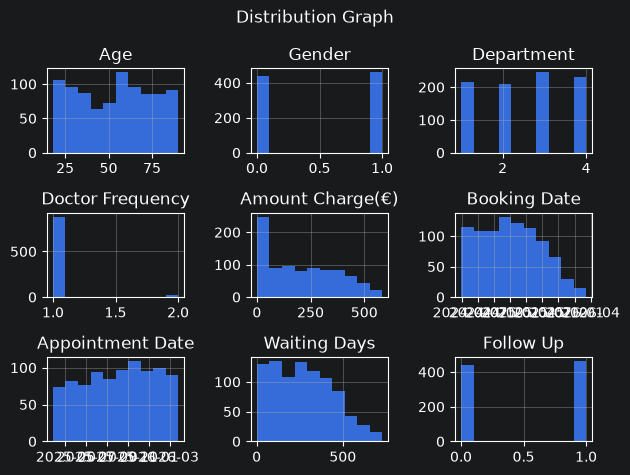

In [41]:
#EDA Stage.
#Univariant analysis; histogram graph for distribution
plt.figure(figsize=(10,10))#Size of the plot.
clinic.hist()
plt.suptitle("Distribution Graph", fontsize=12)
plt.tight_layout()
plt.show();

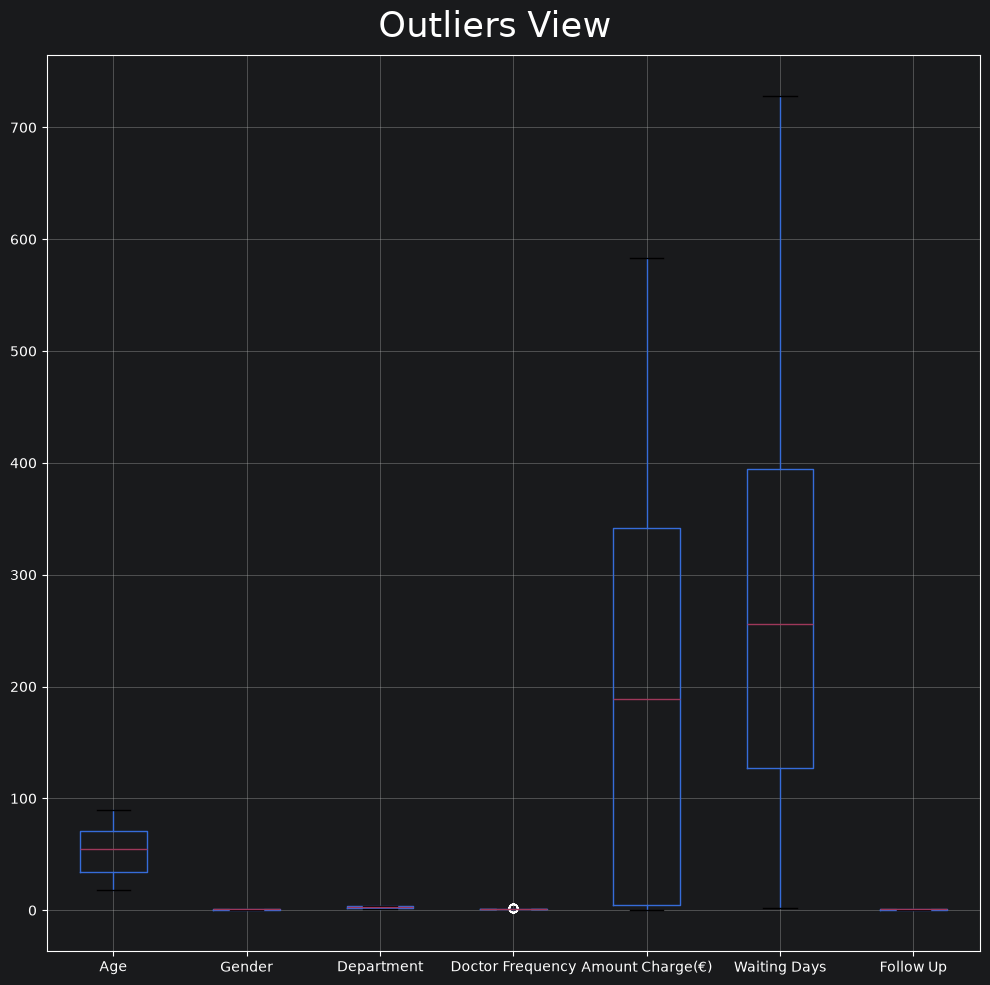

In [42]:
#Boxplot for outliers. change the background to white
plt.figure(figsize=(10,10))#Size of the plot.
clinic.boxplot()
plt.suptitle("Outliers View", fontsize=25)
plt.tight_layout()
plt.show();

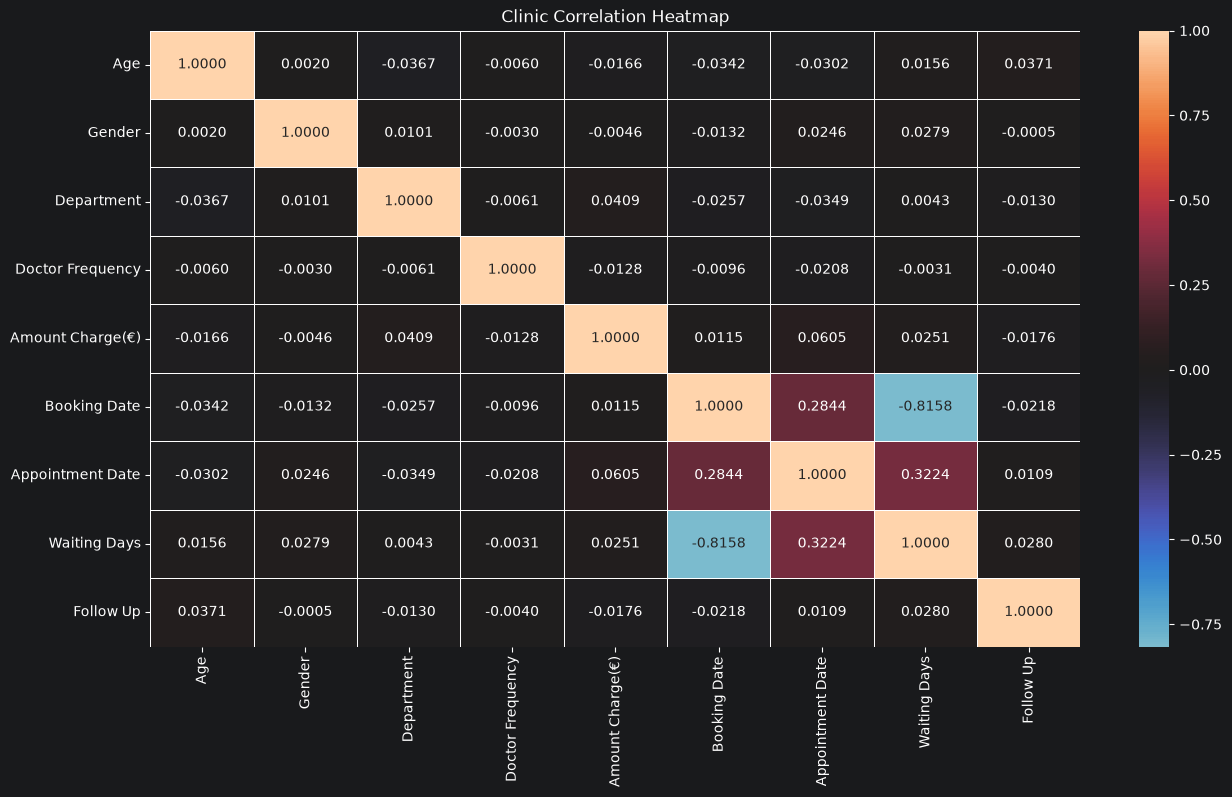

In [43]:
#Multivariant Analysis: correlation heatmap
clinic_heatmap = clinic.drop("Doctor", axis = 1).corr()
plt.figure(figsize=(15,8))
sns.heatmap(clinic_heatmap, annot=True, fmt='.4f', center=0,linewidths=.5)
plt.title('Clinic Correlation Heatmap')
plt.show();

<Figure size 2500x1800 with 0 Axes>

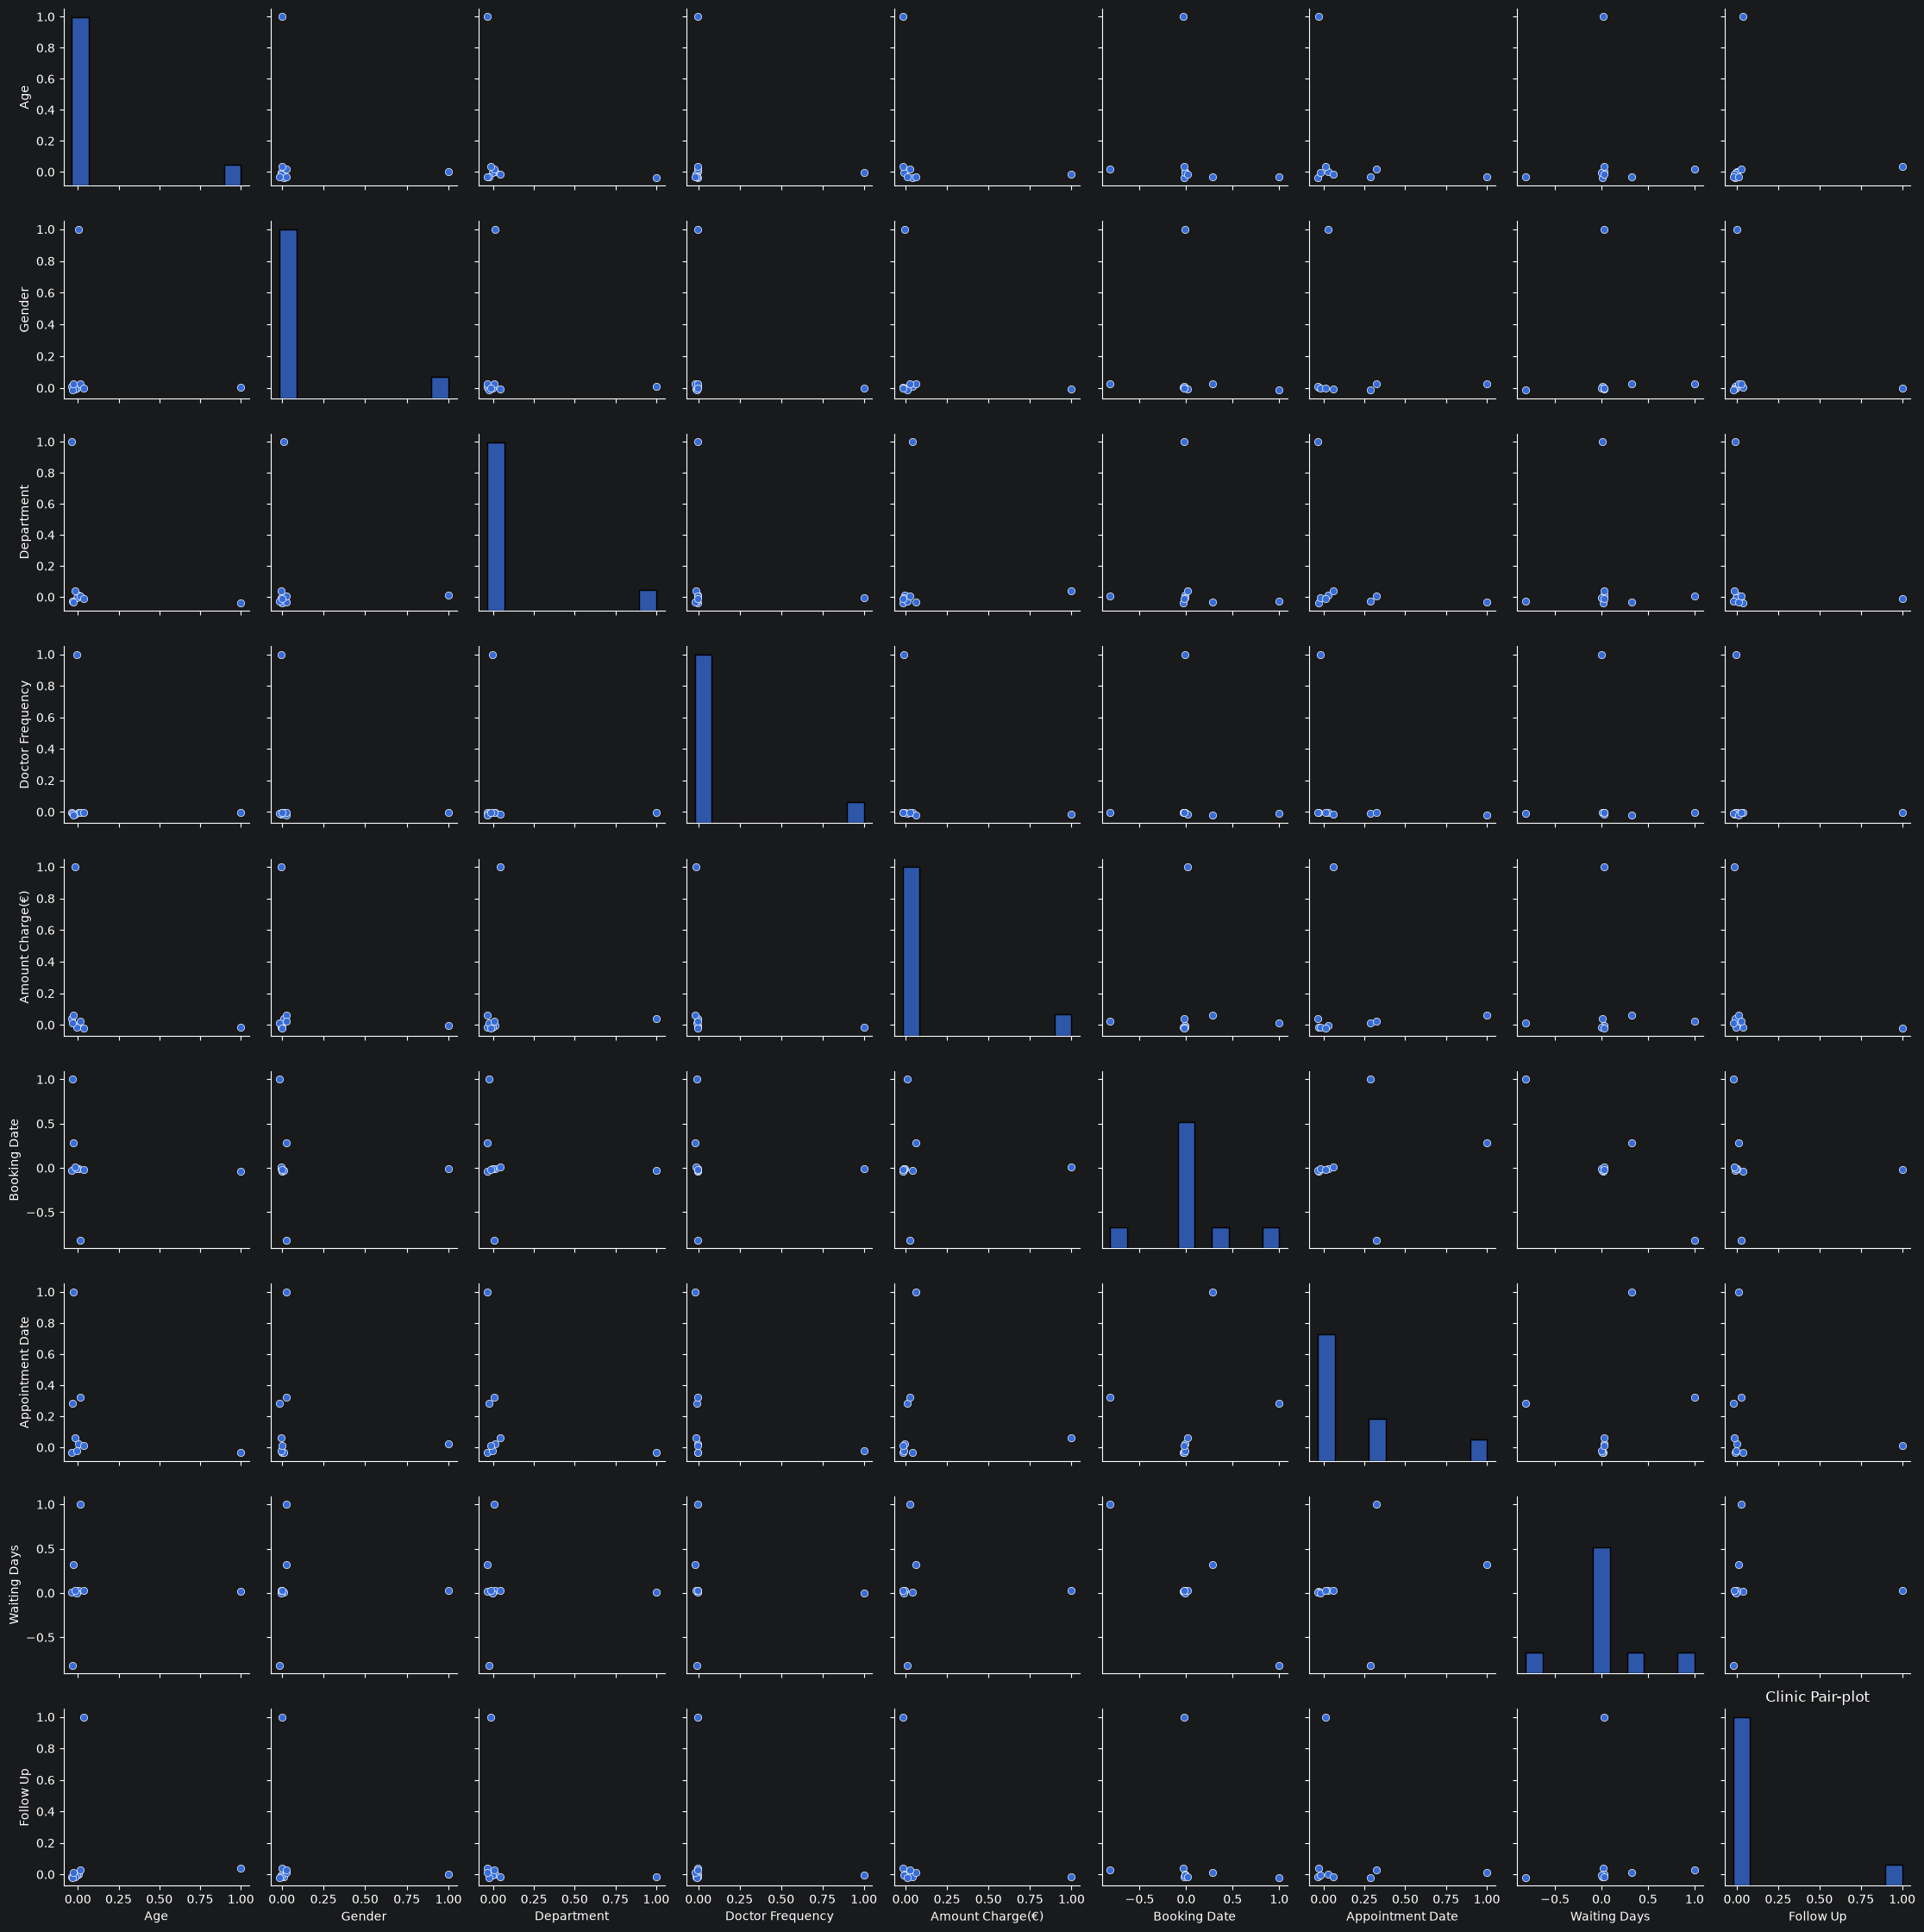

In [44]:
# Pair_plot for visualization
plt.figure(figsize=(25,18))
sns.pairplot(clinic_heatmap,diag_kind="hist",plot_kws={},diag_kws={"bins":10})
plt.title("Clinic Pair-plot")
plt.tight_layout()
plt.show();

<Figure size 2500x1800 with 0 Axes>

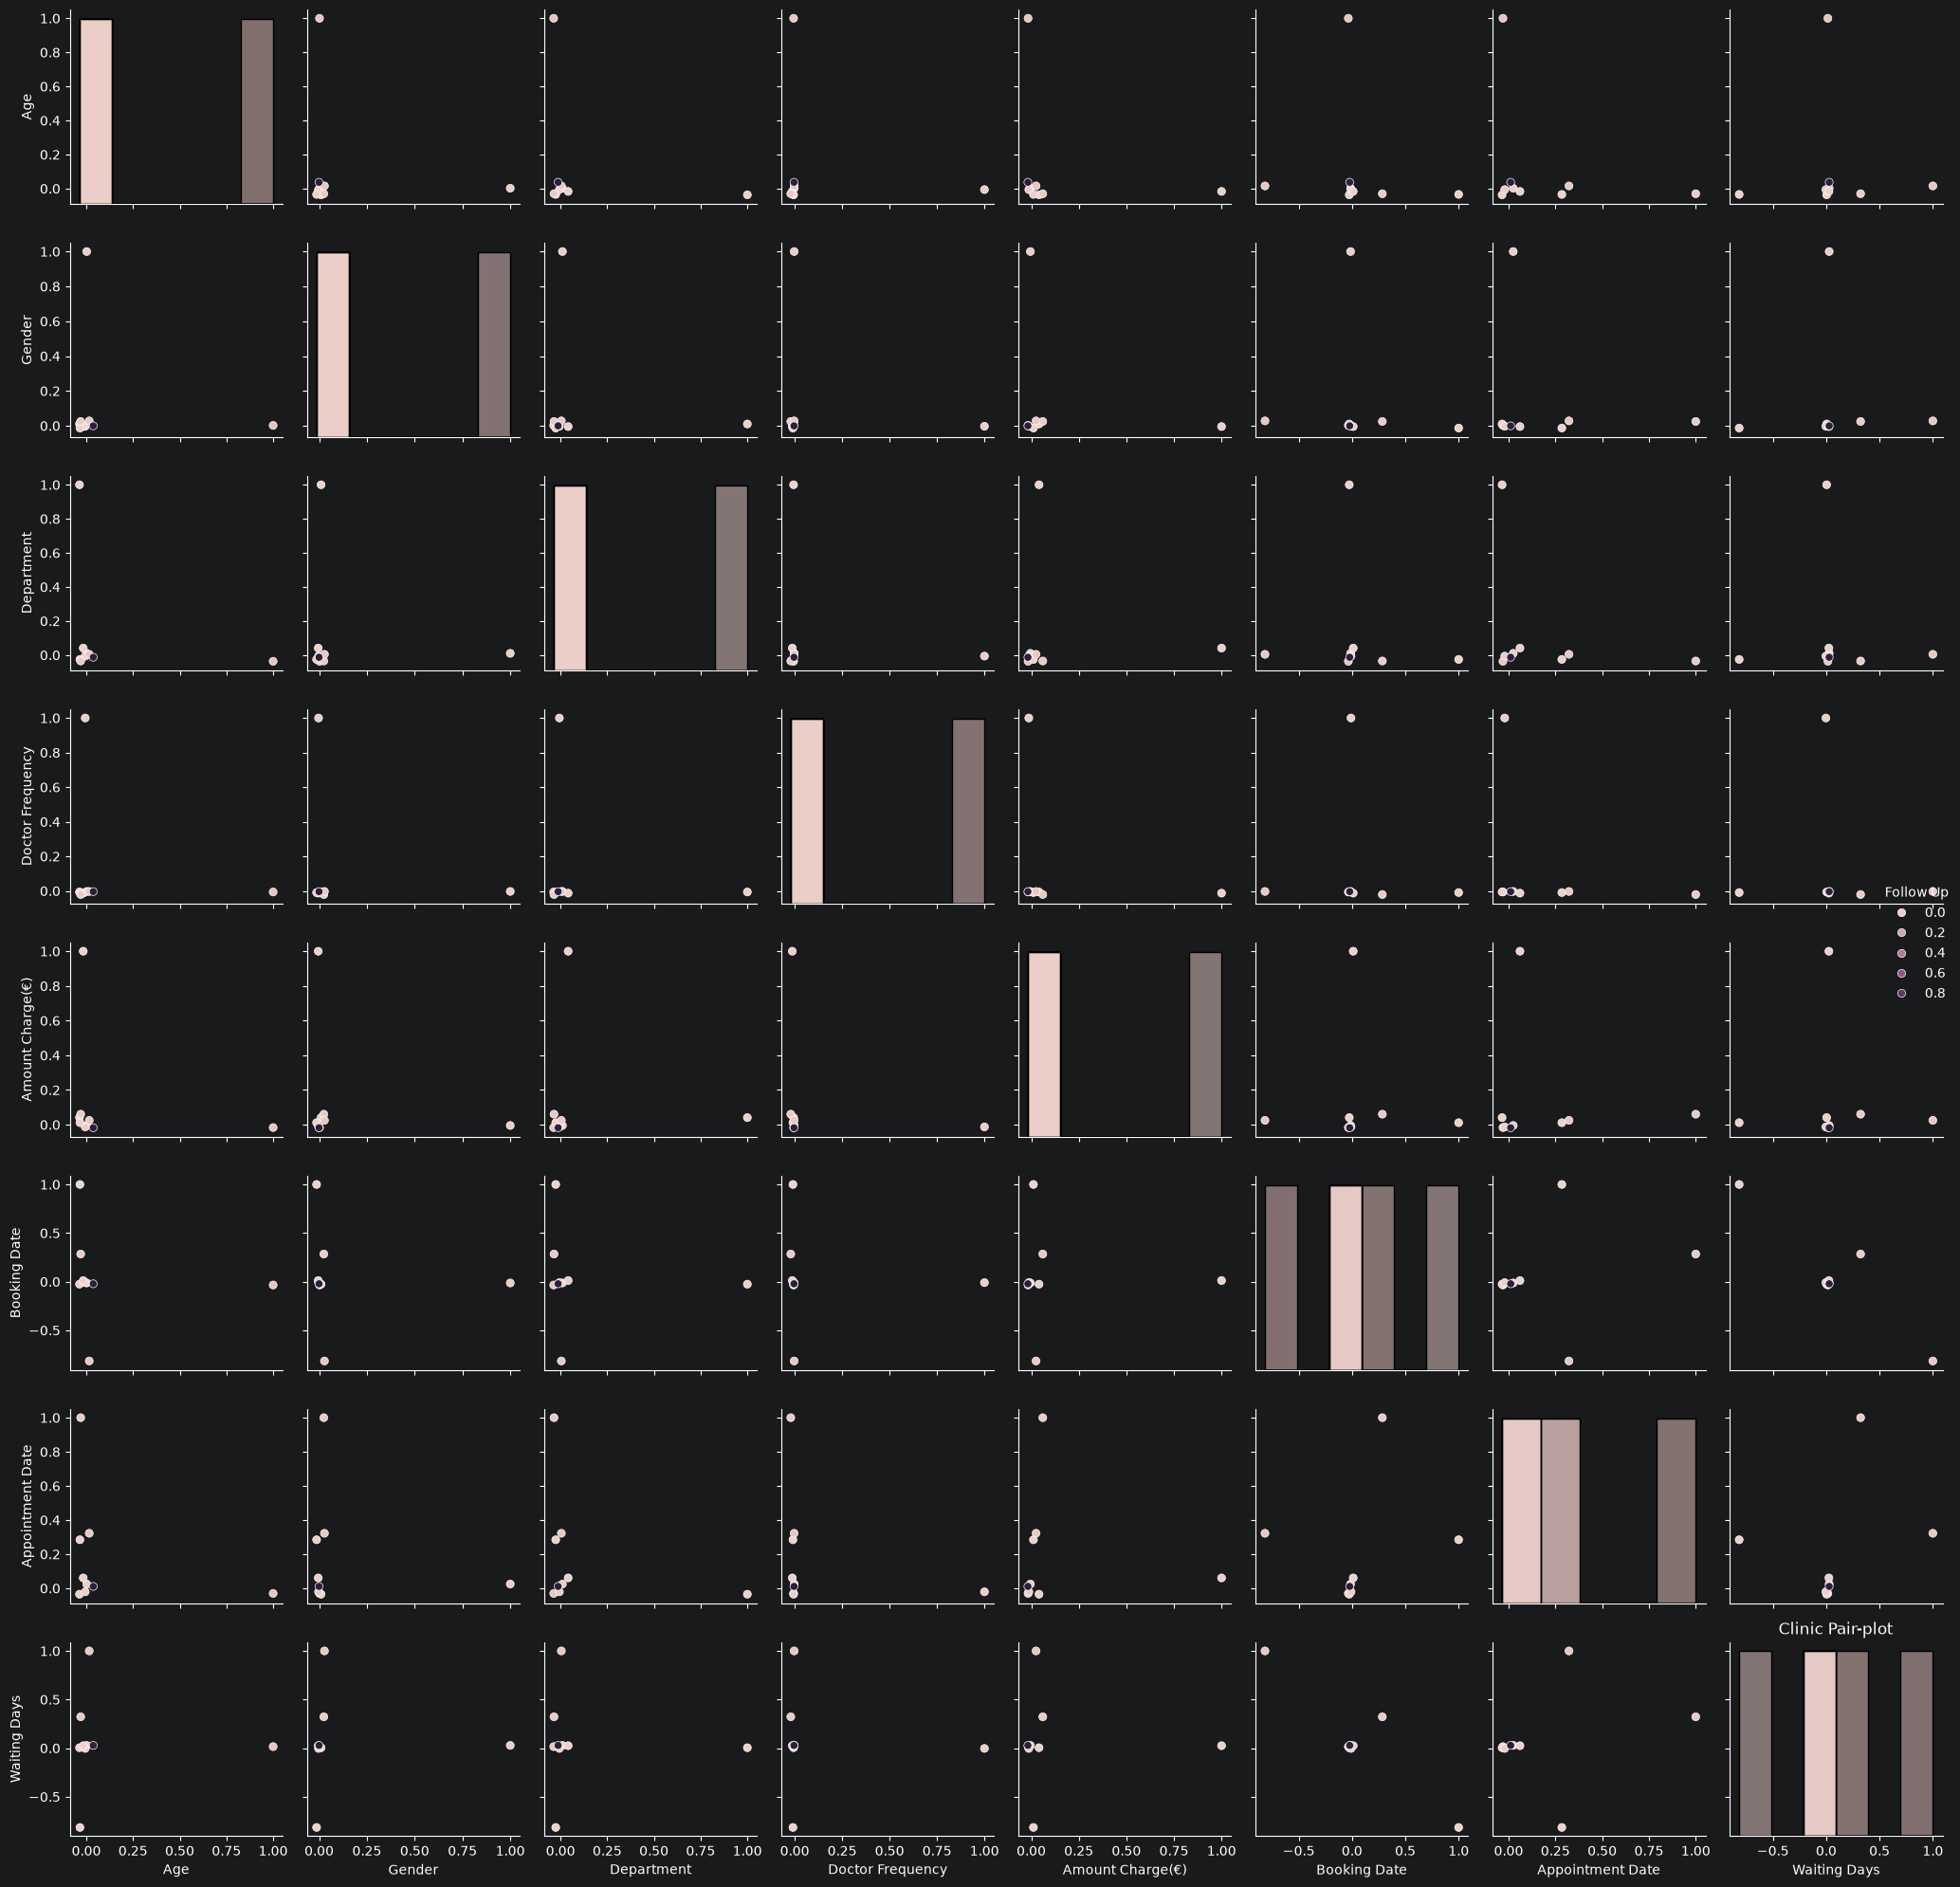

In [45]:
#Pair-plot for visualization:target variable as hue
plt.figure(figsize=(25,18))
sns.pairplot(clinic_heatmap,hue="Follow Up",diag_kind="hist")
plt.title("Clinic Pair-plot")
plt.tight_layout()
plt.show();

In [46]:
#Validate the dataset for model training
#Note: the clinic dataframe can be use also, I just want to improve on using the sklearn preprocessing tools.
clinic_copy2 = clinic_copy2.drop(columns=["Doctor","Booking Date","Appointment Date"])
clinic_copy2.info()

<class 'pandas.DataFrame'>
Index: 902 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Age               902 non-null    int64         
 1   Gender            902 non-null    str           
 2   Department        902 non-null    str           
 3   Amount Charge(€)  902 non-null    float64       
 4   Appointment Date  902 non-null    datetime64[us]
 5   Waiting Days      902 non-null    int64         
 6   Follow Up         902 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 71.3 KB


In [47]:
#Model Training Stage
#Assign feature and target variables
x = clinic_copy2.drop(columns="Follow Up")
y = clinic_copy2["Follow Up"]

In [48]:
#Split dataset for train, validation and test
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train,x_val,y_train,y_val = train_test_split(x_train,y_train,test_size=0.2,random_state=42)

In [49]:
#Selecting base ML model for the dataset: logistic regressor, decision tree and random forest classifier.
logistic_model = LogisticRegression()
tree_model = DecisionTreeClassifier()
forest_model = RandomForestClassifier()

In [50]:
#Preprocessing the x_train, x_val, and x_test dataset: encoding
encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)

x_train = encoder.fit_transform(x_train)
x_val = encoder.transform(x_val)
x_test = encoder.transform(x_test)

In [51]:
#Train the base models
logistic_model.fit(x_train,y_train)
tree_model.fit(x_train,y_train)
forest_model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [52]:
#Prediction on the validation set
logistic_y_pred = logistic_model.predict(x_val)
tree_y_pred = tree_model.predict(x_val)
forest_y_pred = forest_model.predict(x_val)

In [53]:
#Evaluation metrics: Logistic model
logistic_accuracy = accuracy_score(y_val,logistic_y_pred)
logistic_conmatrix = confusion_matrix(y_val,logistic_y_pred)
logistic_report = classification_report(y_val,logistic_y_pred)
print(f"Logistic_Regression Accuracy: {logistic_accuracy}\nLogistic_Regression Confusion_Matrix:\n{logistic_conmatrix}\nLogistic_Regression Classification_Report:\n{logistic_report}")

#Tree model
tree_accuracy = accuracy_score(y_val,tree_y_pred)
tree_conmatrix = confusion_matrix(y_val,tree_y_pred)
tree_report = classification_report(y_val,tree_y_pred)
print(f"Decision_Tree Accuracy: {tree_accuracy}\nDecision_Tree Confusion_Matrix:\n{tree_conmatrix}\nDecision_Tree Classification_Report:\n{tree_report}")

#Forest model
forest_accuracy = accuracy_score(y_val,forest_y_pred)
forest_conmatrix = confusion_matrix(y_val,forest_y_pred)
forest_report = classification_report(y_val,forest_y_pred)
print(f"Random_Forest Accuracy: {forest_accuracy}\nRandom_Forest Confusion_Matrix:\n{forest_conmatrix}\nRandom_Forest Classification_Report:\n{forest_report}")

Logistic_Regression Accuracy: 0.4689655172413793
Logistic_Regression Confusion_Matrix:
[[29 38]
 [39 39]]
Logistic_Regression Classification_Report:
              precision    recall  f1-score   support

          no       0.43      0.43      0.43        67
         yes       0.51      0.50      0.50        78

    accuracy                           0.47       145
   macro avg       0.47      0.47      0.47       145
weighted avg       0.47      0.47      0.47       145

Decision_Tree Accuracy: 0.4827586206896552
Decision_Tree Confusion_Matrix:
[[23 44]
 [31 47]]
Decision_Tree Classification_Report:
              precision    recall  f1-score   support

          no       0.43      0.34      0.38        67
         yes       0.52      0.60      0.56        78

    accuracy                           0.48       145
   macro avg       0.47      0.47      0.47       145
weighted avg       0.47      0.48      0.47       145

Random_Forest Accuracy: 0.496551724137931
Random_Forest Confusion_

In [54]:
#Validation for models performance
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
score = {"accuracy":"accuracy", "precision":make_scorer(precision_score,pos_label="yes",zero_division=0), "recall":make_scorer(recall_score,pos_label="yes",zero_division=0), "f1":make_scorer(f1_score,pos_label="yes",zero_division=0)}

In [55]:
#Tuning of the models: randomized search cv
#Logistic regression model
logistic_params = {"C":[0.001,0.01,0.1,1,10,100], "solver":["liblinear","lbfgs"], "max_iter":[500,1000,2000]}

logistic_search = RandomizedSearchCV(logistic_model,logistic_params,n_iter=20,cv=cv,scoring=score,refit="accuracy",random_state=42)

logistic_search.fit(x_train,y_train)
logistic_best_model = logistic_search.best_estimator_

print(f"Logistic Regression Best Model: {logistic_best_model}\nAccuracy Score: {logistic_search.best_score_}")

Logistic Regression Best Model: LogisticRegression(C=0.01, max_iter=1000)
Accuracy Score: 0.5294752623688156


In [56]:
#Decision tree model
tree_params = {"max_depth":[None,3,5,10,15,20], "min_samples_split":[2,5,10,20], "min_samples_leaf":[1,2,5,10], "criterion":["gini","entropy"]}

tree_search = RandomizedSearchCV(tree_model,tree_params,n_iter=20,cv=cv,scoring=score,refit="accuracy",random_state=42)

tree_search.fit(x_train,y_train)
tree_best_model = tree_search.best_estimator_

print(f"Decision Tree Best Model: {tree_best_model}\nAccuracy Score: {tree_search.best_score_}")

Decision Tree Best Model: DecisionTreeClassifier(max_depth=15, min_samples_leaf=10)
Accuracy Score: 0.5277211394302848


In [57]:
#Random forest model
forest_params = {"n_estimators":[100,200,300,500], "max_depth":[None,5,10,15,20], "min_samples_split":[2,5,10], "min_samples_leaf":[1,2,5], "max_features":["sqrt","log2",None]}

forest_search = RandomizedSearchCV(forest_model,forest_params,n_iter=20,cv=cv,scoring=score,refit="accuracy",random_state=42)

forest_search.fit(x_train,y_train)
forest_best_model = forest_search.best_estimator_

print(f"Random Forest Best Model: {forest_best_model}\nAccuracy Score: {forest_search.best_score_}")

Random Forest Best Model: RandomForestClassifier(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300)
Accuracy Score: 0.5260119940029985


In [58]:
#Predict and evaluate the best models on the validation set
logistic_best_model_y_pred = logistic_best_model.predict(x_val)
tree_best_model_y_pred = tree_best_model.predict(x_val)
forest_best_model_y_pred = forest_best_model.predict(x_val)

#Logistic model
logistic_tuned_conmatrix = confusion_matrix(y_val,logistic_best_model_y_pred)
logistic_tuned_report = classification_report(y_val,logistic_best_model_y_pred)
print(f"Tuned_Logistic_Regression Confusion_Matrix:\n{logistic_tuned_conmatrix}\nTuned_Logistic_Regression Classification_Report:\n{logistic_tuned_report}")

#Tree model
tree_tuned_conmatrix = confusion_matrix(y_val,tree_best_model_y_pred)
tree_tuned_report = classification_report(y_val,tree_best_model_y_pred)
print(f"Tuned_Decision_Tree Confusion_Matrix:\n{tree_tuned_conmatrix}\nTuned_Decision_Tree Classification_Report:\n{tree_tuned_report}")

#Forest model
forest_tuned_conmatrix = confusion_matrix(y_val,forest_best_model_y_pred)
forest_tuned_report = classification_report(y_val,forest_best_model_y_pred)
print(f"Tuned_Random_Forest Confusion_Matrix:\n{forest_tuned_conmatrix}\nTuned_Random_Forest Classification_Report:\n{forest_tuned_report}")

Tuned_Logistic_Regression Confusion_Matrix:
[[16 51]
 [15 63]]
Tuned_Logistic_Regression Classification_Report:
              precision    recall  f1-score   support

          no       0.52      0.24      0.33        67
         yes       0.55      0.81      0.66        78

    accuracy                           0.54       145
   macro avg       0.53      0.52      0.49       145
weighted avg       0.54      0.54      0.50       145

Tuned_Decision_Tree Confusion_Matrix:
[[23 44]
 [42 36]]
Tuned_Decision_Tree Classification_Report:
              precision    recall  f1-score   support

          no       0.35      0.34      0.35        67
         yes       0.45      0.46      0.46        78

    accuracy                           0.41       145
   macro avg       0.40      0.40      0.40       145
weighted avg       0.41      0.41      0.41       145

Tuned_Random_Forest Confusion_Matrix:
[[21 46]
 [30 48]]
Tuned_Random_Forest Classification_Report:
              precision    recall 

In [64]:
#Prediction on the test set.
logistic_test_pred = logistic_best_model.predict(x_test)
tree_test_pred = tree_best_model.predict(x_test)
forest_test_pred = forest_best_model.predict(x_test)

#Logistic model
logistic_test_conmatrix = confusion_matrix(y_test,logistic_test_pred)
logistic_test_report = classification_report(y_test,logistic_test_pred)
print(f"Test_Logistic_Regression Confusion_Matrix:\n{logistic_test_conmatrix}\nTest_Logistic_Regression Classification_Report:\n{logistic_test_report}")

#Tree model
tree_test_conmatrix = confusion_matrix(y_test,tree_test_pred)
tree_test_report = classification_report(y_test,tree_test_pred)
print(f"Test_Decision_Tree Confusion_Matrix:\n{tree_test_conmatrix}\nTest_Decision_Tree Classification_Report:\n{tree_test_report}")

#Forest model
forest_test_conmatrix = confusion_matrix(y_test,forest_test_pred)
forest_test_report = classification_report(y_test,forest_test_pred)
print(f"Test_Random_Forest Confusion_Matrix:\n{forest_test_conmatrix}\nTest_Random_Forest Classification_Report:\n{forest_test_report}")

Test_Logistic_Regression Confusion_Matrix:
[[15 76]
 [21 69]]
Test_Logistic_Regression Classification_Report:
              precision    recall  f1-score   support

          no       0.42      0.16      0.24        91
         yes       0.48      0.77      0.59        90

    accuracy                           0.46       181
   macro avg       0.45      0.47      0.41       181
weighted avg       0.45      0.46      0.41       181

Test_Decision_Tree Confusion_Matrix:
[[42 49]
 [49 41]]
Test_Decision_Tree Classification_Report:
              precision    recall  f1-score   support

          no       0.46      0.46      0.46        91
         yes       0.46      0.46      0.46        90

    accuracy                           0.46       181
   macro avg       0.46      0.46      0.46       181
weighted avg       0.46      0.46      0.46       181

Test_Random_Forest Confusion_Matrix:
[[33 58]
 [32 58]]
Test_Random_Forest Classification_Report:
              precision    recall  f1-sc

<Figure size 2500x1500 with 0 Axes>

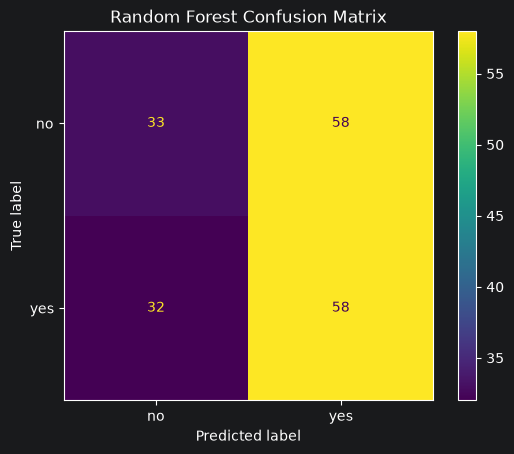

In [74]:
#Plotting the selected model graph
#Confusion matrix
plt.figure(figsize=(25,15))
ConfusionMatrixDisplay.from_predictions(y_test,forest_test_pred)
plt.title("Random Forest Confusion Matrix")
plt.show();

<Figure size 2500x1500 with 0 Axes>

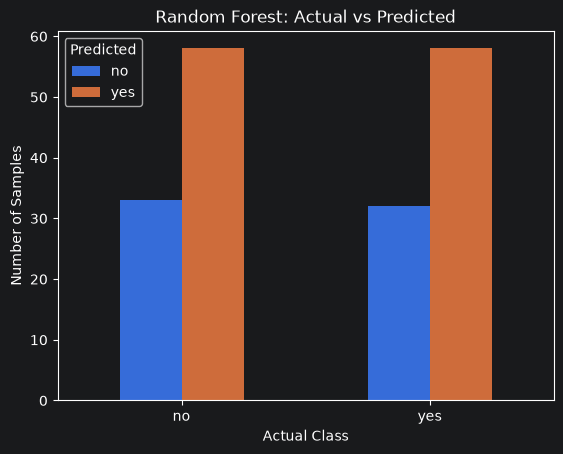

In [75]:
#Comparison graph
forest_result = pd.DataFrame({"Actual": y_test, "Predicted": forest_test_pred})
comparison = pd.crosstab(forest_result["Actual"],forest_result["Predicted"])

plt.figure(figsize=(25,15))
comparison.plot(kind="bar")
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show();

In [ ]:
#Save the selected model and encoder
#joblib.dump(forest_best_model,"FollowUp_Decision_Model.pkl")
#Joblib.dump(encoder,"Hotencoder.pkl")